In [1]:
import numpy as np
import tensorflow as tf

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import random

# ===================== CONFIG =====================
IMAGE_DIR      = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\train\Original'
MASK_DIR       = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\train\Ground truth'
TEST_IMAGE_DIR = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\test\Original'
TEST_MASK_DIR  = r'C:\Users\AUSTCSE4090\Desktop\FIVES\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\FIVES A Fundus Image Dataset for AI-based Vessel Segmentation\test\Ground truth'

RESIZE_SIZE = 512     # Original size of FIVES images
IMG_SIZE    = 128     # Patch size
OVERLAP     = 0.5
BATCH_SIZE  = 8         # Adjust according to GPU
SHUFFLE_BUF = 512

# ===================== AUGMENTATION =====================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ===================== UTIL FUNCTIONS =====================
def is_valid_patch(mask, threshold=0.01):
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches_img, patches_mask = [], []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img  = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)
    
    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)
                     if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    masks = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    return images, masks

# ===================== GENERATOR =====================
def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    for img_path, mask_path in zip(image_paths, mask_paths):
        img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img  = cv2.resize(img,  (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        patches_img, patches_mask = extract_patches(img, mask, IMG_SIZE, OVERLAP, skip_empty)
        
        for p_img, p_mask in zip(patches_img, patches_mask):
            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img  = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ===================== LOAD DATA =====================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Random shuffle for train/val split
combined = list(zip(all_images, all_masks))
random.shuffle(combined)
all_images, all_masks = zip(*combined)

# Validation: 150 images
val_images   = all_images[:150]
val_masks    = all_masks[:150]

# Training: rest of the images
train_images = all_images[150:]
train_masks  = all_masks[150:]

# Test
test_images, test_masks = load_image_mask_paths(TEST_IMAGE_DIR, TEST_MASK_DIR)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

# ===================== TF.DATA DATASETS =====================
output_signature = (
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
)

train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=output_signature
).shuffle(SHUFFLE_BUF).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: generator(val_images, val_masks, augment=False, skip_empty=False),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Datasets ready: train_ds, val_ds, test_ds")

C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train: 450, Val: 150, Test: 200
✅ Datasets ready: train_ds, val_ds, test_ds


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

L2 = 1e-4

# =========================================================
# Basic Conv Block
# =========================================================
def ConvBNAct(x, filters, kernel=3, stride=1, dilation=1, act="relu"):
    x = layers.Conv2D(
        filters, kernel,
        strides=stride,
        padding="same",
        dilation_rate=dilation,
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2)
    )(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation(act)(x)

# =========================================================
# Unified Residual Block (optionally with CAPA)
# =========================================================
def ResidualBlock(x, filters, use_capa=False):
    identity = x

    x = ConvBNAct(x, filters)
    x = ConvBNAct(x, filters)

    if use_capa:
        x = CAPA(x)

    if identity.shape[-1] != filters:
        identity = ConvBNAct(identity, filters, kernel=1)

    return layers.Add()([x, identity])

# =========================================================
# DMLB – Directional Multi-Linear Block
# =========================================================
def DMLB(x, filters):
    h = ConvBNAct(x, filters, kernel=(1,3))
    v = ConvBNAct(x, filters, kernel=(3,1))
    d = ConvBNAct(x, filters, kernel=3)
    x = layers.Concatenate()([h, v, d])
    return ConvBNAct(x, filters, kernel=1)

# =========================================================
# HFR – High Frequency Residual Vessel Enhancement
# =========================================================
def HFR_Vessel(x, filters):
    if x.shape[-1] != filters:
        x = ConvBNAct(x, filters, kernel=1)

    c = x.shape[-1]
    lap = tf.constant([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=tf.float32)
    lap = lap[:,:,None,None]
    lap = tf.tile(lap, [1,1,c,1])

    lap_layer = layers.DepthwiseConv2D(
        3, padding="same",
        use_bias=False,
        trainable=False,
        depthwise_initializer=tf.keras.initializers.Constant(lap)
    )

    x = layers.Add()([x, lap_layer(x)])
    return ConvBNAct(x, filters)

# =========================================================
# Adaptive ConvMixer (Scale-Aware)
# =========================================================
def AdaptiveConvMixer(x, filters):
    branches = []
    for d in [1,2,4,8]:
        y = layers.DepthwiseConv2D(3, padding="same", dilation_rate=d)(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation("silu")(y)
        branches.append(y)

    concat = layers.Concatenate()(branches)
    w = layers.GlobalAveragePooling2D()(concat)
    w = layers.Dense(len(branches), activation="softmax")(w)
    w = layers.Reshape((1,1,len(branches)))(w)

    out = layers.Add()([
        layers.Multiply()([b, layers.Lambda(lambda t, i=i: t[..., i:i+1])(w)])
        for i,b in enumerate(branches)
    ])

    out = layers.Conv2D(filters, 1, padding="same")(out)

    if x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, padding="same")(x)

    return layers.Add()([x, out])

# =========================================================
# CAPA – Channel + Pixel Attention
# =========================================================
def CAPA(x, reduction=8):
    c = x.shape[-1]

    avg = layers.GlobalAveragePooling2D()(x)
    maxp = layers.GlobalMaxPooling2D()(x)

    shared = layers.Dense(c//reduction, activation="relu")
    avg = layers.Dense(c)(shared(avg))
    maxp = layers.Dense(c)(shared(maxp))

    ca = layers.Activation("sigmoid")(layers.Add()([avg, maxp]))
    ca = layers.Reshape((1,1,c))(ca)
    x = layers.Multiply()([x, ca])

    pa = layers.Conv2D(1, 1, activation="sigmoid")(x)
    return layers.Multiply()([x, pa])

# =========================================================
# HRNet Blocks (Topology Preserver)
# =========================================================
def HRNetBlock(x, filters):
    return ResidualBlock(x, filters)

def HRNetStage(branches, channels, blocks=2):
    for i in range(len(branches)):
        for _ in range(blocks):
            branches[i] = HRNetBlock(branches[i], channels[i])

    fused = []
    for i in range(len(branches)):
        y = None
        for j in range(len(branches)):
            x = branches[j]
            if j > i:
                x = layers.Conv2D(channels[i],1,use_bias=False)(x)
                x = layers.BatchNormalization()(x)
                x = layers.UpSampling2D(2**(j-i), interpolation="bilinear")(x)
            elif j < i:
                for _ in range(i-j):
                    x = ConvBNAct(x, channels[i], stride=2)
            y = x if y is None else layers.Add()([y,x])
        fused.append(layers.Activation("gelu")(y))
    return fused

def HRNet(x):
    x = ConvBNAct(x, 64)
    x = ConvBNAct(x, 64)

    x1 = ConvBNAct(x, 30)
    x2 = ConvBNAct(x, 60, stride=2)

    branches = HRNetStage([x1,x2], [30,60])

    x3 = ConvBNAct(branches[-1], 120, stride=2)
    branches = HRNetStage([branches[0],branches[1],x3], [30,60,120])

    outs = [branches[0]]
    for i in range(1,len(branches)):
        outs.append(layers.UpSampling2D(2**i, interpolation="bilinear")(branches[i]))

    return layers.Concatenate()(outs)

# =========================================================
# Encoder
# =========================================================
def encoder(inp):
    x = DMLB(inp, 32)
    x = HFR_Vessel(x, 64)
    F1 = ConvBNAct(x, 64)

    x = ResidualBlock(F1, 96)
    F2 = ConvBNAct(x, 96, stride=2)

    x = ConvBNAct(F2, 128)
    hr = HRNet(x)

    F3 = layers.Concatenate()([
        AdaptiveConvMixer(hr, 160),
        layers.Conv2D(64,1,padding="same")(hr)
    ])

    return F1, F2, F3

# =========================================================
# Decoder
# =========================================================
def decoder(F1, F2, F3, n_classes):
    x = ResidualBlock(F3, 160, use_capa=True)

    x = ConvBNAct(x, 128)
    x = layers.Concatenate()([x, F2])
    x = ResidualBlock(x, 128, use_capa=True)

    x = layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = ConvBNAct(x, 96)
    x = layers.Concatenate()([x, F1])
    x = ResidualBlock(x, 96, use_capa=True)

    x = ResidualBlock(x, 64, use_capa=True)

    return layers.Conv2D(n_classes, 1, activation="sigmoid")(x)

# =========================================================
# Build Model
# =========================================================
def build_model(input_shape=(128,128,3), n_classes=1):
    inp = layers.Input(input_shape)
    F1, F2, F3 = encoder(inp)
    out = decoder(F1, F2, F3, n_classes)
    return models.Model(inp, out, name="RDHCNet")

# =========================================================
# Instantiate
# =========================================================
model = build_model()
model.summary()

Model: "RDHCNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  288         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 32  288         ['input_1[0][0]']                
                                )                                                           

In [3]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [4]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [5]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)




early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,      # 2%
    patience=7,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=[early_stop]
)



Epoch 1/80
2616/2616 [==============================] - 245s 90ms/step - loss: 0.5920 - sensitivity: 0.8244 - specificity: 0.9738 - accuracy: 0.9593 - f1_score: 0.7958 - auc: 0.9594 - dice_coef: 0.7871 - iou: 0.6617 - val_loss: 0.4422 - val_sensitivity: 0.9209 - val_specificity: 0.9785 - val_accuracy: 0.9742 - val_f1_score: 0.8575 - val_auc: 0.9804 - val_dice_coef: 0.8438 - val_iou: 0.7398
Epoch 2/80
2616/2616 [==============================] - 234s 89ms/step - loss: 0.3941 - sensitivity: 0.8896 - specificity: 0.9847 - accuracy: 0.9756 - f1_score: 0.8712 - auc: 0.9739 - dice_coef: 0.8610 - iou: 0.7574 - val_loss: 0.3302 - val_sensitivity: 0.9156 - val_specificity: 0.9860 - val_accuracy: 0.9806 - val_f1_score: 0.8876 - val_auc: 0.9818 - val_dice_coef: 0.8745 - val_iou: 0.7862
Epoch 3/80
2616/2616 [==============================] - 234s 89ms/step - loss: 0.3178 - sensitivity: 0.8969 - specificity: 0.9856 - accuracy: 0.9773 - f1_score: 0.8796 - auc: 0.9760 - dice_coef: 0.8691 - iou: 0.769

Dice        : 0.9007
IoU         : 0.8279
Accuracy    : 0.9877
F1-score    : 0.9007
Sensitivity : 0.9031
Specificity : 0.9932
AUC         : 0.9907


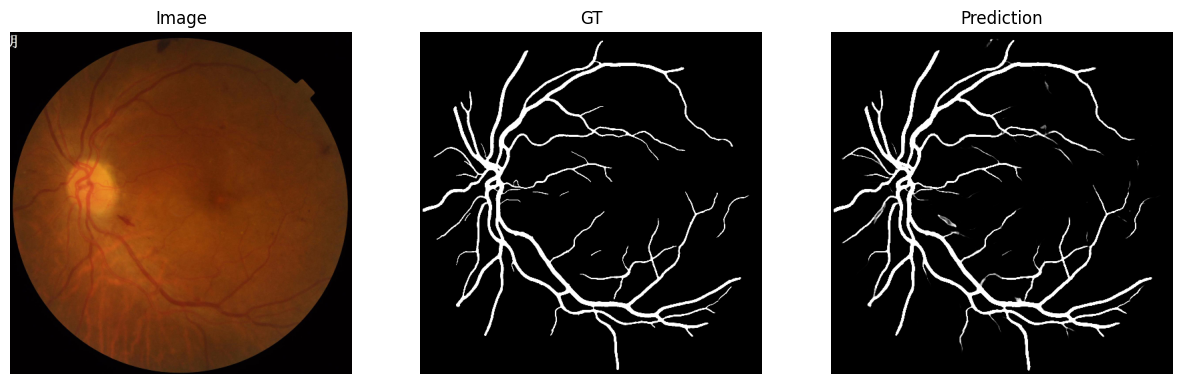

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

# ================= CONFIG =================
RESIZE_SIZE = 512
PATCH_SIZE  = 128
OVERLAP     = 0.5
STRIDE      = int(PATCH_SIZE * (1 - OVERLAP))
BATCH_SIZE  = 16          # GPU safe
THRESHOLD   = 0.5

# ================= PATCH UTILS =================
def extract_patches(img):
    H, W = img.shape[:2]
    for y in range(0, H - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            yield img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

def stitch_patches(patches):
    full = np.zeros((RESIZE_SIZE, RESIZE_SIZE), np.float32)
    count = np.zeros_like(full)

    idx = 0
    for y in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
        for x in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
            full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += patches[idx]
            count[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1
            idx += 1

    return np.clip(full / (count + 1e-7), 0, 1)

# ================= FULL IMAGE PRED =================
def predict_full_image(model, img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = list(extract_patches(img))
    preds_all = []

    for i in range(0, len(patches), BATCH_SIZE):
        batch = np.array(patches[i:i+BATCH_SIZE], np.float32) / 255.0
        preds = model.predict(batch, verbose=0)
        preds_all.extend(preds[..., 0])

    return img, stitch_patches(preds_all)

# ================= EVALUATION =================
def evaluate_model(model, image_paths, mask_paths):
    dice_l, iou_l, acc_l, f1_l, se_l, sp_l, auc_l = [], [], [], [], [], [], []

    for img_p, mask_p in zip(image_paths, mask_paths):
        _, pred = predict_full_image(model, img_p)

        gt = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

        y_prob = pred.flatten()
        y_pred = (pred >= THRESHOLD).astype(np.uint8).flatten()
        y_true = (gt >= 0.5).astype(np.uint8).flatten()

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

        dice = (2*tp) / (2*tp + fp + fn + 1e-7)
        iou  = tp / (tp + fp + fn + 1e-7)
        acc  = (tp + tn) / (tp + tn + fp + fn + 1e-7)
        se   = tp / (tp + fn + 1e-7)
        sp   = tn / (tn + fp + 1e-7)
        f1   = f1_score(y_true, y_pred)
        auc  = roc_auc_score(y_true, y_prob)

        dice_l.append(dice)
        iou_l.append(iou)
        acc_l.append(acc)
        f1_l.append(f1)
        se_l.append(se)
        sp_l.append(sp)
        auc_l.append(auc)

    print(f"Dice        : {np.mean(dice_l):.4f}")
    print(f"IoU         : {np.mean(iou_l):.4f}")
    print(f"Accuracy    : {np.mean(acc_l):.4f}")
    print(f"F1-score    : {np.mean(f1_l):.4f}")
    print(f"Sensitivity : {np.mean(se_l):.4f}")
    print(f"Specificity : {np.mean(sp_l):.4f}")
    print(f"AUC         : {np.mean(auc_l):.4f}")

# ================= VISUALIZATION =================
def visualize(model, img_path, mask_path):
    img, pred = predict_full_image(model, img_path)
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("GT"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pred, cmap="gray"); plt.title("Prediction"); plt.axis("off")
    plt.show()

# ================= RUN =================
evaluate_model(model, test_images, test_masks)
visualize(model, test_images[0], test_masks[0])

In [8]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(model):
    input_shape = [1] + list(model.input_shape[1:])

    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )

    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops


In [9]:
flops = get_flops(model)
print("FLOPs:", flops)
print("GFLOPs:", flops / 1e9)


Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`
FLOPs: 36940185174
GFLOPs: 36.940185174


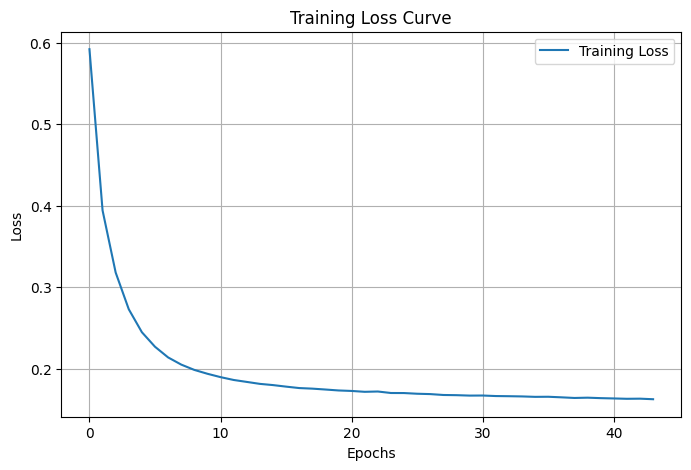

In [11]:
import matplotlib.pyplot as plt

# Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
#plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


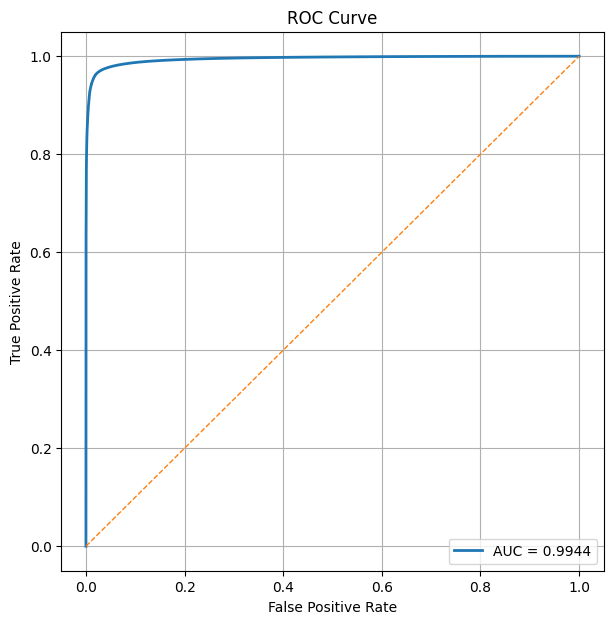

Global AUC: 0.9944323396636783


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
def plot_roc_curve(model, image_paths, mask_paths):
    all_gt = []
    all_pred = []

    for img_path, mask_path in zip(image_paths, mask_paths):
        _, pred_mask = predict_full_image(model, img_path)

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

        gt_bin = (gt_mask >= 0.5).astype(np.uint8)

        all_gt.extend(gt_bin.flatten())
        all_pred.extend(pred_mask.flatten())

    all_gt = np.array(all_gt)
    all_pred = np.array(all_pred)

    # ROC + AUC
    fpr, tpr, thresholds = roc_curve(all_gt, all_pred)
    auc_score = roc_auc_score(all_gt, all_pred)

    # Plot
    plt.figure(figsize=(7,7))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    print("Global AUC:", auc_score)
plot_roc_curve(model, test_images, test_masks)


In [19]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()